# Preparación de los datos
## Librerías y configuraciones

In [36]:
import pandas as pd
import numpy as np
# graficos
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import plotly.express as px

In [47]:
from sklearn.preprocessing import StandardScaler # Estandarización con z-score
from imblearn.under_sampling import RandomUnderSampler # Balanceo de clases por undersampling
from sklearn.model_selection import train_test_split

In [19]:
# configuración formateo
pd.options.display.max_columns = None
pd.options.display.max_colwidth = 100
pd.options.display.width = 1000

#pd.reset_option('display.max_columns')
pd.reset_option('display.max_colwidth')
pd.reset_option('display.width')

pd.set_option('display.expand_frame_repr', False) 

## Extracción del archivo tratado

In [20]:
data_src_path = './TelecomX_Data_prepared.csv'
df = pd.read_csv(data_src_path)

In [21]:
df

,CHURN,ES_HOMBRE,ES_MAYOROIGUAL_65ANIOS,TIENE_PAREJA,TIENE_DEPENDIENTES,NUM_MESES_CONTRATO,TIENE_SEGURIDAD_ENLINEA,TIENE_RESPALDO_ENLINEA,TIENE_PROTECCION_DISPOSITIVO,TIENE_SOPORTE_TECNICO_MAYOR,TIENE_TV_CABLE,TIENE_STREAM_PELIS,ES_FACTURA_ENLINEA,TOTAL_SERV_MES_DOLARES,TOTAL_GASTADO_DOLARES,TOTAL_SERV_MESXDIA_DOLARES,ES_CONTRATO_XMES,ES_CONTRATO_XANIO,ES_CONTRATO_X2ANIOS,ES_PAGO_TRANSF_BANCARIA,ES_PAGO_TARJ_CRED,ES_PAGO_ELECTRONICO,ES_PAGO_POR_CORREO,ES_PAGO_AUTOMATICO,TIENE_1_LIN_TEL,TIENE_MASDE_1_LIN_TEL,TIENE_SERV_INTERNET,TIENE_INTERNET_DSL
0,False,False,False,True,True,9,False,True,False,True,True,False,True,65.60,593.30,2.186667,False,True,False,False,False,False,True,False,True,False,True,True
1,False,True,False,False,False,9,False,False,False,False,False,True,False,59.90,542.40,1.996667,True,False,False,False,False,False,True,False,False,True,True,True
2,True,True,False,False,False,4,False,False,True,False,False,False,True,73.90,280.85,2.463333,True,False,False,False,False,True,False,False,True,False,True,False
3,True,True,True,True,False,13,False,True,True,False,True,True,True,98.00,1237.85,3.266667,True,False,False,False,False,True,False,False,True,False,True,False
4,True,False,True,True,False,3,False,False,False,True,True,False,True,83.90,267.40,2.796667,True,False,False,False,False,False,True,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,False,False,False,False,False,13,True,False,False,True,False,False,False,55.15,742.90,1.838333,False,True,False,False,False,False,True,False,True,False,True,True
7039,True,True,False,True,False,22,False,False,False,False,False,True,True,85.10,1873.70,2.836667,True,False,False,False,False,True,False,False,False,True,True,False
7040,False,True,False,False,False,2,False,True,False,False,False,False,True,50.30,92.75,1.676667,True,False,False,False,False,False,True,False,True,False,True,True
7041,False,True,False,True,True,67,True,False,True,True,False,True,False,67.85,4627.65,2.261667,False,False,True,False,False,False,True,False,True,False,True,True


## Eliminación de Columnas Irrelevantes
Esto ya se realizó en la fase uno ([Notebook explicado a detalle](TelecomX_LATAM.ipynb)), siendo que la primera columna irrelevante y eliminada fue `customerID`. Sin embargo, la columna de 'TOTAL_SERV_MESXDIA_DOLARES' ('CuentasDiarias'), es irrelevante por presentar la misma información que 'account.Charges.Monthly' o 'TOTAL_SERV_MES_DOLARES' por lo que se eliminará y creará una columna más relevante 'TOTAL_GASTADOXMES_DOLARES'.

In [22]:
df.drop(columns='TOTAL_SERV_MESXDIA_DOLARES', inplace=True)

In [23]:
df['TOTAL_GASTADOXMES_DOLARES'] = df['TOTAL_GASTADO_DOLARES'] / df['NUM_MESES_CONTRATO']

In [24]:
df

,CHURN,ES_HOMBRE,ES_MAYOROIGUAL_65ANIOS,TIENE_PAREJA,TIENE_DEPENDIENTES,NUM_MESES_CONTRATO,TIENE_SEGURIDAD_ENLINEA,TIENE_RESPALDO_ENLINEA,TIENE_PROTECCION_DISPOSITIVO,TIENE_SOPORTE_TECNICO_MAYOR,TIENE_TV_CABLE,TIENE_STREAM_PELIS,ES_FACTURA_ENLINEA,TOTAL_SERV_MES_DOLARES,TOTAL_GASTADO_DOLARES,ES_CONTRATO_XMES,ES_CONTRATO_XANIO,ES_CONTRATO_X2ANIOS,ES_PAGO_TRANSF_BANCARIA,ES_PAGO_TARJ_CRED,ES_PAGO_ELECTRONICO,ES_PAGO_POR_CORREO,ES_PAGO_AUTOMATICO,TIENE_1_LIN_TEL,TIENE_MASDE_1_LIN_TEL,TIENE_SERV_INTERNET,TIENE_INTERNET_DSL,TOTAL_GASTADOXMES_DOLARES
0,False,False,False,True,True,9,False,True,False,True,True,False,True,65.60,593.30,False,True,False,False,False,False,True,False,True,False,True,True,65.922222
1,False,True,False,False,False,9,False,False,False,False,False,True,False,59.90,542.40,True,False,False,False,False,False,True,False,False,True,True,True,60.266667
2,True,True,False,False,False,4,False,False,True,False,False,False,True,73.90,280.85,True,False,False,False,False,True,False,False,True,False,True,False,70.212500
3,True,True,True,True,False,13,False,True,True,False,True,True,True,98.00,1237.85,True,False,False,False,False,True,False,False,True,False,True,False,95.219231
4,True,False,True,True,False,3,False,False,False,True,True,False,True,83.90,267.40,True,False,False,False,False,False,True,False,True,False,True,False,89.133333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,False,False,False,False,False,13,True,False,False,True,False,False,False,55.15,742.90,False,True,False,False,False,False,True,False,True,False,True,True,57.146154
7039,True,True,False,True,False,22,False,False,False,False,False,True,True,85.10,1873.70,True,False,False,False,False,True,False,False,False,True,True,False,85.168182
7040,False,True,False,False,False,2,False,True,False,False,False,False,True,50.30,92.75,True,False,False,False,False,False,True,False,True,False,True,True,46.375000
7041,False,True,False,True,True,67,True,False,True,True,False,True,False,67.85,4627.65,False,False,True,False,False,False,True,False,True,False,True,True,69.069403


## Encoding
Esto ya se realizó en la fase uno ([Notebook explicado a detalle](TelecomX_LATAM.ipynb)).
## Verificación de la Proporción de Cancelación (Churn)
Desde la fase anterior se verificó que hay desbalance de clases, incluso en la variable objetivo de 'CHURN'

In [25]:
print(df.value_counts('CHURN'))

CHURN
False    5174
True     1869
Name: count, dtype: int64


## Balanceo de clases
Se aplica undersampling a la clase mayoritaria (False) para que ambas clases tengan números de registros iguales o similares.

In [26]:
# Configurar el rus
rus = RandomUnderSampler(random_state=0)

In [27]:
df_resampled, y_resampled = rus.fit_resample(df, df['CHURN']) 

### Mostrar resultados

In [28]:
df_resampled

,CHURN,ES_HOMBRE,ES_MAYOROIGUAL_65ANIOS,TIENE_PAREJA,TIENE_DEPENDIENTES,NUM_MESES_CONTRATO,TIENE_SEGURIDAD_ENLINEA,TIENE_RESPALDO_ENLINEA,TIENE_PROTECCION_DISPOSITIVO,TIENE_SOPORTE_TECNICO_MAYOR,TIENE_TV_CABLE,TIENE_STREAM_PELIS,ES_FACTURA_ENLINEA,TOTAL_SERV_MES_DOLARES,TOTAL_GASTADO_DOLARES,ES_CONTRATO_XMES,ES_CONTRATO_XANIO,ES_CONTRATO_X2ANIOS,ES_PAGO_TRANSF_BANCARIA,ES_PAGO_TARJ_CRED,ES_PAGO_ELECTRONICO,ES_PAGO_POR_CORREO,ES_PAGO_AUTOMATICO,TIENE_1_LIN_TEL,TIENE_MASDE_1_LIN_TEL,TIENE_SERV_INTERNET,TIENE_INTERNET_DSL,TOTAL_GASTADOXMES_DOLARES
366,False,False,False,True,False,28,False,False,False,False,False,False,False,20.50,563.05,True,False,False,False,False,False,True,False,True,False,False,False,20.108929
3031,False,False,False,False,False,62,False,False,False,False,False,False,True,25.80,1563.95,False,False,True,False,True,False,False,True,False,True,False,False,25.225000
20,False,False,True,True,False,50,False,False,False,False,False,False,False,25.20,1306.30,False,True,False,False,False,True,False,False,False,True,False,False,26.126000
4192,False,True,False,False,False,2,False,False,False,False,False,False,False,20.05,42.70,True,False,False,False,False,False,True,False,True,False,False,False,21.350000
189,False,False,False,False,True,11,True,False,False,True,False,False,True,36.05,402.60,False,True,False,False,False,False,True,False,False,False,True,True,36.600000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7020,True,True,True,False,False,21,False,False,True,False,True,True,True,96.80,2030.30,True,False,False,True,False,False,False,True,True,False,True,False,96.680952
7023,True,True,True,False,False,9,False,False,False,False,False,True,True,83.85,790.15,True,False,False,False,False,True,False,False,False,True,True,False,87.794444
7036,True,False,False,False,False,1,False,False,False,False,False,False,True,70.15,70.15,True,False,False,False,False,False,True,False,True,False,True,False,70.150000
7037,True,False,False,False,False,4,False,False,False,False,False,False,False,20.95,85.50,True,False,False,True,False,False,False,True,True,False,False,False,21.375000


In [29]:
y_resampled

366     False
3031    False
20      False
4192    False
189     False
        ...  
7020     True
7023     True
7036     True
7037     True
7039     True
Name: CHURN, Length: 3738, dtype: bool

In [30]:
print(df_resampled.value_counts('CHURN'))

CHURN
False    1869
True     1869
Name: count, dtype: int64


## Normalización o Estandarización 

### Comprender distribución para elegir normalizar o estandarizar

In [31]:
df_resampled.describe(include=[np.number])

,NUM_MESES_CONTRATO,TOTAL_SERV_MES_DOLARES,TOTAL_GASTADO_DOLARES,TOTAL_GASTADOXMES_DOLARES
count,3738.000000,3738.000000,3732.000000,3732.000000
mean,27.544141,67.823248,2038.614295,67.831046
std,23.974058,28.950140,2194.774039,29.081939
min,0.000000,18.550000,18.800000,14.150000
25%,5.000000,45.300000,267.550000,45.156250
50%,21.000000,74.650000,1128.600000,74.339001
75%,48.000000,90.800000,3239.662500,91.328906
max,72.000000,118.650000,8684.800000,121.400000


Los datos parecen asimétricos en sus distribuciones (en especial en las variables de NUM_MESES_CONTRATO y TOTAL_GASTADO_DOLARES) por lo que es mejor utilizar estandarización en los datos en caso de usar modelos como KNN o regresión logística.

In [33]:
scaler = StandardScaler() # objeto de estandarización

Es necesario aplicarlo una vez se haya dividido el conjunto de datos de entrenamiento y prueba.

# Corrección y Selección de variables
## Análisis de correlación

In [35]:
corr_matrix = df_resampled.corr()

                                 CHURN  ES_HOMBRE  ES_MAYOROIGUAL_65ANIOS  TIENE_PAREJA  TIENE_DEPENDIENTES  NUM_MESES_CONTRATO  TIENE_SEGURIDAD_ENLINEA  TIENE_RESPALDO_ENLINEA  TIENE_PROTECCION_DISPOSITIVO  TIENE_SOPORTE_TECNICO_MAYOR  TIENE_TV_CABLE  TIENE_STREAM_PELIS  ES_FACTURA_ENLINEA  TOTAL_SERV_MES_DOLARES  TOTAL_GASTADO_DOLARES  ES_CONTRATO_XMES  ES_CONTRATO_XANIO  ES_CONTRATO_X2ANIOS  ES_PAGO_TRANSF_BANCARIA  ES_PAGO_TARJ_CRED  ES_PAGO_ELECTRONICO  ES_PAGO_POR_CORREO  ES_PAGO_AUTOMATICO  TIENE_1_LIN_TEL  TIENE_MASDE_1_LIN_TEL  TIENE_SERV_INTERNET  TIENE_INTERNET_DSL  TOTAL_GASTADOXMES_DOLARES
CHURN                         1.000000  -0.026223                0.165819     -0.170204           -0.180902           -0.399027                -0.197277               -0.088797                     -0.089080                    -0.190732        0.078735            0.064279            0.211727                0.228633              -0.231323          0.498339          -0.235750            -0.

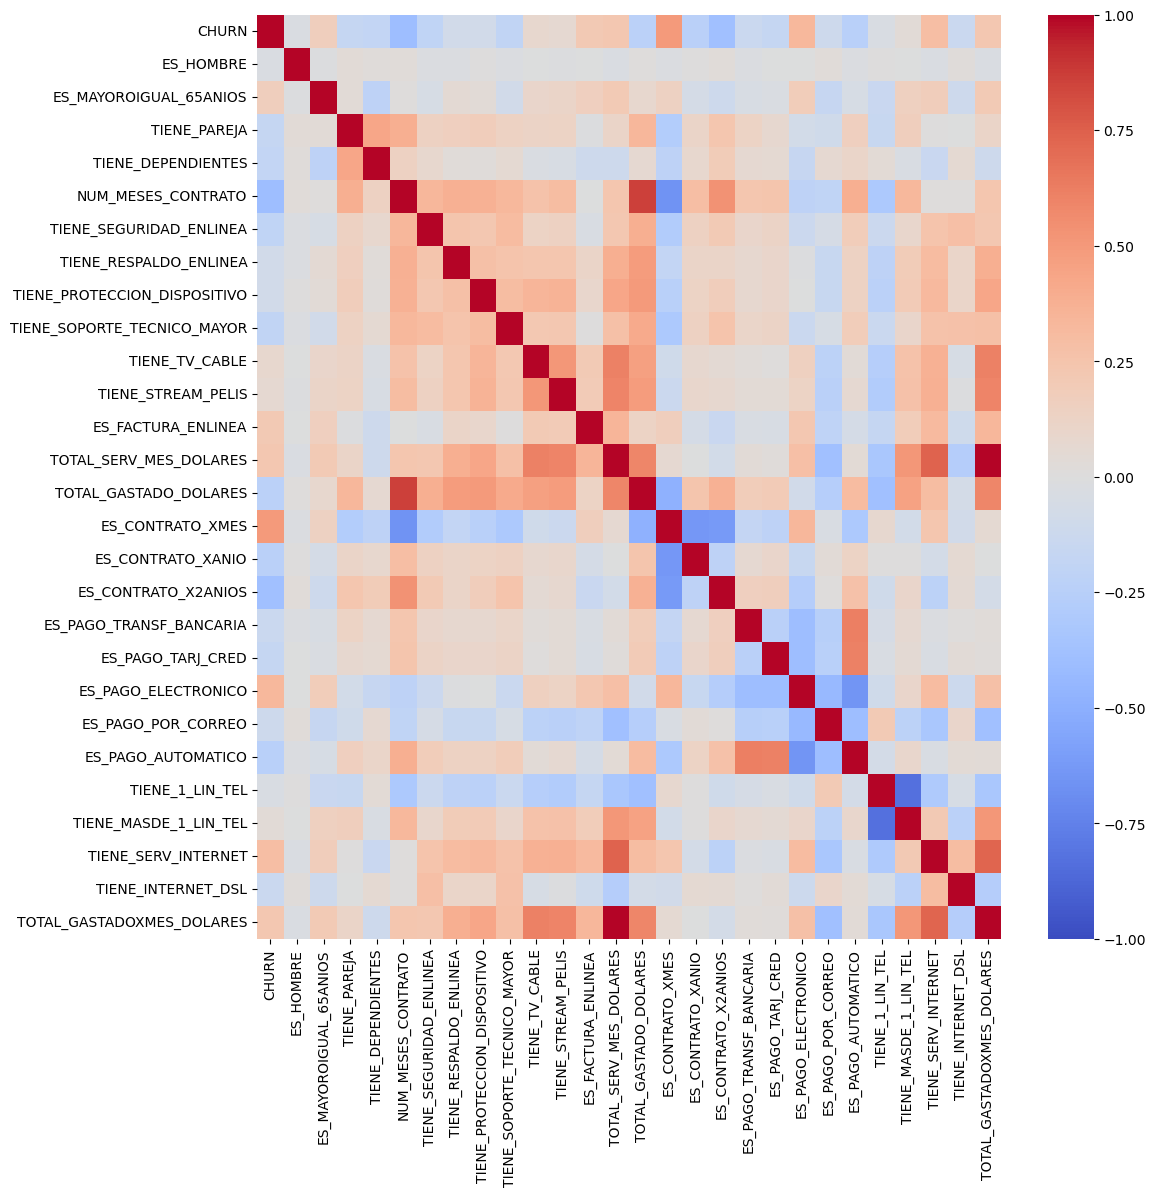

In [41]:
# Visualizarla
print(corr_matrix)
plt.figure(figsize=(12, 12))  # Ajusta el tamaño según sea necesario
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.show()

In [44]:
# Variables más correlacionadas con churn en orden
#candidate_variables_in_order = np.sort((abs(corr_matrix['CHURN'])))[::-1]
correlation_with_churn = corr_matrix['CHURN'].abs()

# Ordena los valores y guarda el índice correspondiente
sorted_correlation = correlation_with_churn.sort_values(ascending=False)


In [46]:
for column, value in sorted_correlation.items():
    print(f"{column}:\t\t\t{value:.4f}")

CHURN:			1.0000
ES_CONTRATO_XMES:			0.4983
NUM_MESES_CONTRATO:			0.3990
ES_CONTRATO_X2ANIOS:			0.3901
ES_PAGO_ELECTRONICO:			0.3324
TIENE_SERV_INTERNET:			0.2930
ES_PAGO_AUTOMATICO:			0.2425
ES_CONTRATO_XANIO:			0.2357
TOTAL_GASTADO_DOLARES:			0.2313
TOTAL_SERV_MES_DOLARES:			0.2286
TOTAL_GASTADOXMES_DOLARES:			0.2274
ES_FACTURA_ENLINEA:			0.2117
TIENE_SEGURIDAD_ENLINEA:			0.1973
TIENE_SOPORTE_TECNICO_MAYOR:			0.1907
TIENE_DEPENDIENTES:			0.1809
TIENE_PAREJA:			0.1702
ES_MAYOROIGUAL_65ANIOS:			0.1658
ES_PAGO_TARJ_CRED:			0.1648
ES_PAGO_TRANSF_BANCARIA:			0.1354
TIENE_INTERNET_DSL:			0.1339
ES_PAGO_POR_CORREO:			0.1122
TIENE_PROTECCION_DISPOSITIVO:			0.0891
TIENE_RESPALDO_ENLINEA:			0.0888
TIENE_TV_CABLE:			0.0787
TIENE_STREAM_PELIS:			0.0643
TIENE_MASDE_1_LIN_TEL:			0.0378
TIENE_1_LIN_TEL:			0.0343
ES_HOMBRE:			0.0262


## Análisis Dirigido
Este procedimiento ya se había hecho en la fase uno ([Notebook explicado a detalle](TelecomX_LATAM.ipynb)). Estos son los resultados especificos:

### Número de meses contratados X Churn
![image.png](./graficas_informe/image%2027.png)

Los clientes con mayor tasa de evasión suelen tener menos de 10 meses contratados

### Total de servicio por mes X Churn
![image.png](./graficas_informe/image%2028.png)

Los clientes que gastan más de 60 dólares al mes suelen tener una alta tasa de evasión.

### Total gastado X Churn
![image.png](./graficas_informe/image%2029.png)

El 50% de clientes que cancelaron contrato lo hicieron cuando gastaron un máximo de ~134 dólares. 

# Modelo predictivo
## Separación de datos

In [51]:
X_train, X_test, y_train, y_test = train_test_split(df_resampled.drop(columns='CHURN', inplace=False), df_resampled['CHURN'], test_size=0.3, random_state=42)

### Resultado

In [52]:
X_train

,ES_HOMBRE,ES_MAYOROIGUAL_65ANIOS,TIENE_PAREJA,TIENE_DEPENDIENTES,NUM_MESES_CONTRATO,TIENE_SEGURIDAD_ENLINEA,TIENE_RESPALDO_ENLINEA,TIENE_PROTECCION_DISPOSITIVO,TIENE_SOPORTE_TECNICO_MAYOR,TIENE_TV_CABLE,TIENE_STREAM_PELIS,ES_FACTURA_ENLINEA,TOTAL_SERV_MES_DOLARES,TOTAL_GASTADO_DOLARES,ES_CONTRATO_XMES,ES_CONTRATO_XANIO,ES_CONTRATO_X2ANIOS,ES_PAGO_TRANSF_BANCARIA,ES_PAGO_TARJ_CRED,ES_PAGO_ELECTRONICO,ES_PAGO_POR_CORREO,ES_PAGO_AUTOMATICO,TIENE_1_LIN_TEL,TIENE_MASDE_1_LIN_TEL,TIENE_SERV_INTERNET,TIENE_INTERNET_DSL,TOTAL_GASTADOXMES_DOLARES
1045,True,False,True,True,7,False,True,False,True,True,False,True,89.75,608.80,True,False,False,False,False,True,False,False,True,False,True,False,86.971429
2928,False,False,False,False,21,False,True,True,False,False,True,True,90.05,1862.90,True,False,False,False,False,True,False,False,True,False,True,False,88.709524
2946,True,False,False,False,2,False,False,False,False,False,False,False,20.35,33.20,True,False,False,False,False,False,True,False,True,False,False,False,16.600000
3870,False,False,False,False,22,True,False,False,False,False,False,True,49.80,1049.05,True,False,False,False,False,True,False,False,True,False,True,True,47.684091
2093,False,False,False,False,29,False,False,False,False,False,False,True,74.20,1993.25,True,False,False,False,False,True,False,False,False,True,True,False,68.732759
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
164,False,False,True,True,16,True,False,True,False,True,True,False,100.70,1522.70,True,False,False,True,False,False,False,True,True,False,True,False,95.168750
5491,True,False,True,True,66,False,False,False,False,False,False,True,19.75,1344.50,False,False,True,False,False,False,True,False,True,False,False,False,20.371212
306,True,False,False,False,33,False,True,False,True,False,False,False,80.60,2651.10,False,False,True,True,False,False,False,True,True,False,True,False,80.336364
6110,True,False,False,False,4,False,False,True,False,False,False,True,29.65,118.50,True,False,False,False,False,True,False,False,False,False,True,True,29.625000


In [54]:
y_train

1045     True
2928    False
2946     True
3870    False
2093    False
        ...  
164     False
5491    False
306     False
6110     True
4815     True
Name: CHURN, Length: 2616, dtype: bool

In [53]:
X_test

,ES_HOMBRE,ES_MAYOROIGUAL_65ANIOS,TIENE_PAREJA,TIENE_DEPENDIENTES,NUM_MESES_CONTRATO,TIENE_SEGURIDAD_ENLINEA,TIENE_RESPALDO_ENLINEA,TIENE_PROTECCION_DISPOSITIVO,TIENE_SOPORTE_TECNICO_MAYOR,TIENE_TV_CABLE,TIENE_STREAM_PELIS,ES_FACTURA_ENLINEA,TOTAL_SERV_MES_DOLARES,TOTAL_GASTADO_DOLARES,ES_CONTRATO_XMES,ES_CONTRATO_XANIO,ES_CONTRATO_X2ANIOS,ES_PAGO_TRANSF_BANCARIA,ES_PAGO_TARJ_CRED,ES_PAGO_ELECTRONICO,ES_PAGO_POR_CORREO,ES_PAGO_AUTOMATICO,TIENE_1_LIN_TEL,TIENE_MASDE_1_LIN_TEL,TIENE_SERV_INTERNET,TIENE_INTERNET_DSL,TOTAL_GASTADOXMES_DOLARES
1163,False,False,False,False,42,True,True,True,True,False,True,True,54.75,2348.45,False,True,False,False,False,True,False,False,False,False,True,True,55.915476
331,True,False,True,True,25,False,False,False,False,False,False,True,19.15,477.60,True,False,False,False,False,False,True,False,True,False,False,False,19.104000
2124,True,False,False,False,9,False,False,False,False,False,False,True,24.60,190.10,True,False,False,False,False,False,True,False,False,False,True,True,21.122222
3761,False,False,True,False,63,True,False,True,False,False,False,True,81.15,5224.50,False,True,False,False,True,False,False,True,True,False,True,False,82.928571
5886,True,False,False,False,12,False,False,True,False,True,True,False,95.70,1184.00,False,True,False,False,False,True,False,False,True,False,True,False,98.666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3918,True,False,True,True,1,False,False,False,False,False,False,False,19.90,19.90,True,False,False,False,False,False,True,False,True,False,False,False,19.900000
1417,True,False,True,False,37,False,False,False,False,False,False,False,20.35,697.65,True,False,False,True,False,False,False,True,True,False,False,False,18.855405
6454,True,False,False,False,1,False,False,False,False,False,False,True,24.45,24.45,True,False,False,False,False,False,True,False,False,False,True,True,24.450000
5071,True,True,True,False,16,True,True,False,False,False,False,True,54.55,825.10,True,False,False,True,False,False,False,True,True,False,True,True,51.568750
